# Imports

In [3]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

from ciim.src.common import base_dir, plots_dir, datasets_e, datasets_a, datasets_all, cell_types, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, palette_minor_types

plt.rcParams['font.family'] = 'Arial'  # Arial or 'Liberation Sans'
default_font = matplotlib.rcParams['font.family']

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")



# Gene-disease assosiations

In [ ]:
# !wget --recursive --no-parent --no-host-directories --cut-dirs 6 ftp://ftp.ebi.ac.uk/pub/databases/opentargets/platform/25.06/output/association_overall_direct .

In [21]:
if False:
    # - moved to prior
    path = "association_overall_direct"

    # Load all Parquet files in the folder
    df = pd.read_parquet(path)
    print(df.head())
import pandas as pd
import os
import json
df = pd.read_parquet(f'{base_dir}/prior/association_overall_direct')

In [ ]:
# - mapping disease id to names
def get_disease_labels(efo_ids):
    labels = {}
    for efo_id in efo_ids:
        url = f"https://www.ebi.ac.uk/ols/api/ontologies/efo/terms?obo_id={efo_id.replace(':', '_')}"
        r = requests.get(url)
        if r.ok and r.json()["page"]["totalElements"] > 0:
            label = r.json()["_embedded"]["terms"][0]["label"]
            labels[efo_id] = label
    return labels

efo_ids = df["diseaseId"].unique().tolist()
disease_map = get_disease_labels(efo_ids)

import json
with open("disease_map.json", "w") as f:
    json.dump(disease_map, f, indent=4)


In [5]:
import requests

def batch_get_gene_symbols(ensembl_ids, batch_size=1000):
    gene_map = {}
    url = "https://mygene.info/v3/query"

    for i in range(0, len(ensembl_ids), batch_size):
        batch_ids = ensembl_ids[i:i + batch_size]
        params = {
            "q": ",".join(batch_ids),
            "scopes": "ensembl.gene",
            "fields": "symbol",
            "species": "human"
        }
        try:
            r = requests.post(url, data=params)
            r.raise_for_status()
            for hit in r.json():
                if "symbol" in hit and "query" in hit:
                    gene_map[hit["query"]] = hit["symbol"]
        except Exception as e:
            print(f"Failed batch {i}-{i+batch_size}: {e}")
    return gene_map

ensembl_ids = df['targetId'].unique().tolist()
gene_map = batch_get_gene_symbols(ensembl_ids)

In [22]:
# - convert the names and save 
with open(f"{base_dir}/prior/disease_map.json", "r") as f:
    disease_map = json.load(f)

df["disease_name"] = df["diseaseId"].map(disease_map)
df["gene_name"] = df["targetId"].map(gene_map)

In [23]:
df = df[~(df['disease_name'].isna() | df['gene_name'].isna())]

In [26]:
df = df[['disease_name', 'gene_name', 'score', 'evidenceCount']]

In [27]:
df.to_csv(f'{base_dir}/prior/disease_gene_association.csv', index=False)

In [ ]:
# check the known targets of drugs
# !wget --recursive --no-parent --no-host-directories --cut-dirs 6 ftp://ftp.ebi.ac.uk/pub/databases/opentargets/platform/25.06/output/known_drug .

In [30]:
from ciim.src.feature_association.helper import get_consensus_net
cell_type = 'CD8T'
net = get_consensus_net(cell_type=cell_type)

In [38]:
net['source'].nunique()

(183,
 array(['ABLIM1', 'ACTN1', 'AHNAK', ..., 'DOCK5', 'FRY', 'TGFBR3L'],
       dtype=object))

In [33]:
df_sub = df[df['gene_name'].isin(net['source'])].reset_index(drop=True) #TODO: check the targets of tfs

<Axes: >

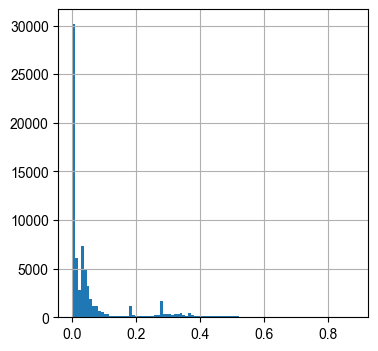

In [46]:
df_sub['score'].hist(bins=100)

In [55]:
df_sub = df_sub[(df_sub['score']>.2)&(df_sub['evidenceCount']>2)].reset_index(drop=True)
df_sub['gene_name'].nunique(), df_sub['disease_name'].nunique()
df_sub[df_sub['gene_name']=='SOX4']

,disease_name,gene_name,score,evidenceCount
224,bladder tumor,SOX4,0.368957,9
254,breast carcinoma,SOX4,0.303573,6
306,clear cell renal carcinoma,SOX4,0.202694,4
340,Crohn's disease,SOX4,0.483807,9
359,cutaneous melanoma,SOX4,0.226558,6
373,diabetes mellitus,SOX4,0.393004,12
490,injury,SOX4,0.324223,3
606,psoriasis,SOX4,0.344005,3
703,ulcerative colitis,SOX4,0.367706,8
731,melanoma,SOX4,0.235743,60


# Extend collecTRI by adding indivitual sources to edges

In [8]:
from ciim.src.utils.util import flesh_out_collectri
flesh_out_collectri()

In [9]:
curated_net = pd.read_csv('/vol/projects/jnourisa/prior/collectri_with_source.csv')
curated_net['ref'].unique()

array(['DoRothEA-A', 'ExTRI', 'HTRI', 'Pavlidis2021', 'TFactS', 'TRRUST',
       'GEREDB', 'CytReg', 'SIGNOR', 'GOA', 'IntAct'], dtype=object)

# Valid gene names

In [4]:
# def get_known_gene_names():
if True:
    import pandas as pd
    gtf_cols = [
        'seqname', 'source', 'feature', 'start', 'end',
        'score', 'strand', 'frame', 'attribute'
    ]

    gtf_path = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/gencode.v47.annotation.gtf.gz'

    gtf_df = pd.read_csv(
        gtf_path,
        sep='\t',
        compression='gzip',
        comment='#',
        header=None,
        names=gtf_cols,
        engine='python'
    )
    import re

    # Define known chromosomes (as strings)
    known_chromosomes = [f'chr{i}' for i in range(1, 21)] + ['X', 'Y']

    # Filter rows where feature is 'gene' and on a known chromosome
    genes_df = gtf_df[
        (gtf_df['feature'] == 'gene') &
        (gtf_df['seqname'].isin(known_chromosomes))
    ].copy()

    # Function to extract gene_name from the attribute column
    def extract_gene_name(attr_str):
        match = re.search(r'gene_name "([^"]+)"', attr_str)
        return match.group(1) if match else None

    # Apply the function
    genes_df['gene_name'] = genes_df['attribute'].apply(extract_gene_name)
    print(genes_df['gene_name'].nunique())

    # Drop NA (just in case) and get unique gene names
    gene_names = genes_df['gene_name'].dropna().unique().tolist()
    np.savetxt(
        '/vol/projects/jnourisa/prior/gene_names.txt',
        gene_names,
        fmt='%s'
    )
# get_known_gene_names()

70759


In [5]:
gtf_df['attribute'].

,seqname,source,feature,start,end,score,strand,frame,attribute
0,chr1,HAVANA,gene,11121,24894,.,+,.,"gene_id ""ENSG00000290825.2""; gene_type ""lncRNA..."
1,chr1,HAVANA,transcript,11121,14413,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
2,chr1,HAVANA,exon,11121,11211,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
3,chr1,HAVANA,exon,12010,12227,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
4,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
...,...,...,...,...,...,...,...,...,...
4105480,chrM,ENSEMBL,transcript,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
4105481,chrM,ENSEMBL,exon,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
4105482,chrM,ENSEMBL,gene,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; gene_type ""Mt_tRN..."
4105483,chrM,ENSEMBL,transcript,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; transcript_id ""EN..."


# Promotor based skeleton

In [2]:
net1 = pd.read_csv(f'/home/jnourisa/projs/ongoing/task_grn_inference/output/skeleton/skeleton_encode_promotor.csv')
net1['edge'] = net1['source'] + '_' + net1['target']

net2 = pd.read_csv(f'/home/jnourisa/projs/ongoing/task_grn_inference/output/skeleton/skeleton_jaspar_promotor.csv')
net2['edge'] = net2['source'] + '_' + net2['target']



In [9]:
net = pd.concat([net1, net2])
net.drop_duplicates(subset=['edge'], inplace=True)
net = net[['source', 'target', 'edge']].reset_index(drop=True)

In [11]:
net.to_csv(f'/vol/projects/jnourisa/prior/skeleton_promotor.csv', index=False)

# For the overview figure

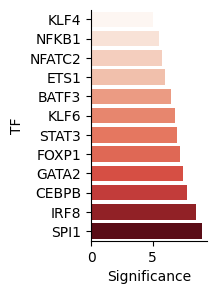

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Example data with more TFs
df = pd.DataFrame({
    'TF': ['SPI1', 'IRF8', 'CEBPB', 'GATA2', 'FOXP1', 'STAT3', 
           'KLF6', 'BATF3', 'ETS1', 'NFATC2', 'NFKB1', 'KLF4'],
    'Importance': np.array([0.9, 0.85, 0.78, 0.75, 0.72, 0.70, 0.68, 0.65, 0.6, 0.58, 0.55, 0.5])*10
})

# Sort values for better visualization
df = df.sort_values(by='Importance', ascending=True)

# Create color gradient based on importance
norm = plt.Normalize(df['Importance'].min(), df['Importance'].max())
colors = sns.color_palette("Reds", as_cmap=True)(norm(df['Importance']))

# Plot
plt.figure(figsize=(1.5, 3))
ax = sns.barplot(data=df, y='TF', x='Importance', palette=colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Significance')
plt.ylabel('TF')
# plt.title('Robust predictors of age')

plt.show()

# Create Pseudocell


In [ ]:

dataset = 'data12' #CXCL9 


def assign_metacells(df, groupby_col, metacell_size=15):
    df = df.copy()
    metacell_id = np.empty(len(df), dtype=object)

    # Create a Series of indices to preserve order
    for group in df[groupby_col].unique():
        mask = df[groupby_col] == group
        idx = np.flatnonzero(mask)
        n_metacells = int(np.ceil(len(idx) / metacell_size))
        ids = np.repeat([f"{group}_MC{i}" for i in range(n_metacells)], metacell_size)[:len(idx)]
        metacell_id[idx] = ids

    df['metacell_id'] = metacell_id
    return df

def normalize(adata):
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    return adata
def create_metacell(adata, sum_by_col):
    from task_grn_inference.src.utils.util import sum_by
    adata.obs[sum_by_col] = adata.obs[sum_by_col].astype('category')
    print(adata.obs[sum_by_col].nunique())
    adata_bulk = sum_by(adata, sum_by_col, unique_mapping=True)
    adata_bulk = normalize(adata_bulk)

    # merge the remaining metadata
    adata_bulk.obs['__original_index__'] = adata_bulk.obs.index
    merged_obs = adata_bulk.obs.merge(
        adata.obs,
        on=sum_by_col,
        how='left',
        suffixes=('', '_from_single')
    )
    merged_obs = merged_obs.drop_duplicates(subset=sum_by_col, keep='last')
    merged_obs = merged_obs.set_index('__original_index__').loc[adata_bulk.obs.index]
    adata_bulk.obs = merged_obs
    return adata_bulk

def main_metacell(dataset):
    # - read the data
    adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad')
    adata = adata[ ~adata.obs.isna().any(axis=1), :]
    # - group by before metacells
    cols = ['cell_type', 'dataset', 'donor_id', 'age', 'treatment']
    available_cols = [col for col in cols if col in adata.obs.columns]
    adata.obs['groupby_col'] = adata.obs[available_cols].astype(str).agg('_'.join, axis=1)

    # - assign metacells
    adata.obs = assign_metacells(adata.obs, groupby_col='groupby_col', metacell_size=15)
    adata.obs.head()[['groupby_col', 'metacell_id']]

    # - create metacells
    adata_metacell = create_metacell(adata, sum_by_col='metacell_id')

    # - save
    cols = ['dataset', 'sex', 'donor_id', 'age', 'cell_type']
    if 'treatment' in adata_metacell.obs.columns:
        cols.append('treatment')
    if 'disease' in adata_metacell.obs.columns:
        cols.append('disease')
    adata_metacell.obs = adata_metacell.obs[cols]
    print(adata_metacell.shape)
    adata_metacell.write(f'/vol/projects/jnourisa/datasets/{dataset}_metacell.h5ad')
for dataset in ['SLE_Asian', 'data7_allTPs_jalil', 'data13_Korean' , 'data13_Japanese']:
    print(dataset)
    main_metacell(dataset)
sc.pp.highly_variable_genes(adata_metacell, n_top_genes=2000, subset=True)
sc.pp.neighbors(adata_metacell)
sc.tl.umap(adata_metacell)
sc.pl.pca(adata_metacell, color=['cell_type'])

# Meta analysis schematic

Spearman correlations per cohort:

Meta-analysis combined p-value (Fisher's method): 4.773365455332607e-150


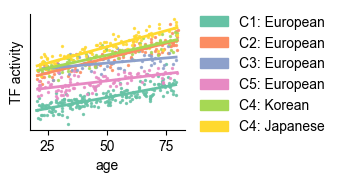

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, combine_pvalues
import matplotlib.pyplot as plt

# Step 1: Generate random data
np.random.seed(42)  # for reproducibility

n_samples_list = [200, 100, 60, 100, 80, 100]  # number of samples per cohort
cohorts = [surrogate_names[d] for d in datasets_all]

data = []

# Define base slope and intercept
base_slope = 0.05
base_intercept = 0.5

for i,cohort in enumerate(cohorts):
    n_samples = n_samples_list[i]
    ages = np.random.uniform(20, 80, size=n_samples)
    
    # Slight random shifts in slope and intercept for each cohort
    slope_shift = np.random.normal(0, 0.02)
    intercept_shift = np.random.normal(0, 4)
    
    tf_activity = (base_slope + slope_shift) * ages + (base_intercept + intercept_shift)
    tf_activity += np.random.normal(0, 0.5, size=n_samples)  # add noise
    
    cohort_df = pd.DataFrame({
        'cohort': cohort,
        'age': ages,
        'tf_activity': tf_activity
    })
    
    data.append(cohort_df)

# Combine into one dataframe
data_df = pd.concat(data, ignore_index=True)
data_df['cohort'] = data_df['cohort'].astype(pd.CategoricalDtype(categories=cohorts, ordered=True))
# Step 2: Calculate Spearman correlation per cohort
results = []
for cohort in cohorts:
    subset = data_df[data_df['cohort'] == cohort]
    corr, pval = spearmanr(subset['age'], subset['tf_activity'])
    results.append({'cohort': cohort, 'spearman_corr': corr, 'pval': pval})

results_df = pd.DataFrame(results)
print("Spearman correlations per cohort:")
_, combined_pval = combine_pvalues(results_df['pval'])

print("\nMeta-analysis combined p-value (Fisher's method):", combined_pval)

# (Optional) Step 4: Plotting
import seaborn as sns
colors = list(palette_datasets.values())
fig, ax = plt.subplots(figsize=(2, 1.5))
for i, cohort in enumerate(data_df['cohort'].unique()):
    subset = data_df[data_df['cohort'] == cohort]
    sns.regplot(data=subset, x='age', y='tf_activity', ax=ax, 
                scatter_kws={'s': 2}, line_kws={'linewidth':2},
                color=colors[i], label=cohort, ci=None)

# ax.legend(title='Cohort', loc=(1.1, .2), frameon=False)
p_values = [1E-20, 1E-10, 1E-5, 1E-2, 0.05, 0.1]  # Example p-values for each cohort
legend_handles = []
for i, d in enumerate(cohorts):
    p_value = p_values[i]
    legend_label = d 
    handle = mpatches.Patch(color=colors[i], label=legend_label)
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1.1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_yticks([])
ax.set_ylabel('TF activity')
plt.savefig(f'{plots_dir}/dummy_meta.png', dpi=300, bbox_inches='tight')
# plt.title('Meta correlation analysis', pad=20)

# Preprocess perturbation datasets

In [11]:
!ls /vol/projects/CIIM/PerturbationDataset/Perturb_seq_dataset_Xiara

HCT116_filtered_dual_guide_cells.h5ad
HCT116_filtered_dual_guide_cells.h5ad.md5
HEK293T_filtered_dual_guide_cells.h5ad
HEK293T_filtered_dual_guide_cells.h5ad.md5


In [14]:
cell_types = ['HEK293T', 'HCT116'] #Human Embryonic Kidney 293T cells, Human Colorectal Carcinoma Cell Line 116
cell_type = cell_types[1]
adata = ad.read_h5ad(f'/vol/projects/CIIM/PerturbationDataset/Perturb_seq_dataset_Xiara/{cell_type}_filtered_dual_guide_cells.h5ad', backed='r')
adata

AnnData object with n_obs × n_vars = 3409169 × 38606 backed at '/vol/projects/CIIM/PerturbationDataset/Perturb_seq_dataset_Xiara/HCT116_filtered_dual_guide_cells.h5ad'
    obs: 'sample', 'num_features', 'guide_target', 'gene_target', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_guide_filter'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [15]:
obs = adata.obs.copy()
obs['is_control'] =  obs['gene_target'] == 'Non-Targeting'
obs['gene_target'] = obs['gene_target'].astype('str')
obs['guide_target'] = obs['guide_target'].astype('str')
obs['sample_gene_target'] = obs['sample'].astype('str') + '_' + obs['gene_target'].astype('str')


print('Number of unique gene and guide targets:', obs['gene_target'].nunique(), obs['guide_target'].nunique())

Number of unique gene and guide targets: 18294 20845


In [18]:
obs[obs['gene_target']=='KLF6']['sample'].value_counts()

sample
HCT116_Batch70    4
HCT116_Batch43    3
HCT116_Batch31    3
HCT116_Batch75    3
HCT116_Batch52    3
                 ..
HCT116_Batch25    0
HCT116_Batch78    0
HCT116_Batch24    0
HCT116_Batch80    0
HCT116_Batch1     0
Name: count, Length: 109, dtype: int64

In [17]:
obs[~obs['is_control']]['sample'].value_counts()

sample
HCT116_Batch20    35576
HCT116_Batch21    35156
HCT116_Batch22    34947
HCT116_Batch23    34721
HCT116_Batch78    34618
                  ...  
HCT116_Batch48    18080
HCT116_Batch2     17795
HCT116_Batch4     17682
HCT116_Batch1     17658
HCT116_Batch66    17099
Name: count, Length: 109, dtype: int64

In [3]:
controls = obs[obs['is_control']]
non_controls = obs[~obs['is_control']]

control_qc = controls.groupby('sample').agg({
    'n_genes_by_counts': ['median', 'mean'],
    'total_counts': ['median', 'mean'],
    'pct_counts_mt': ['median', 'mean'],
    'pass_guide_filter': 'mean'
})
control_qc

NameError: name 'obs' is not defined

In [60]:
non_control_qc = non_controls.groupby('sample').agg({
    'n_genes_by_counts': ['median', 'mean'],
    'total_counts': ['median', 'mean'],
    'pct_counts_mt': ['median', 'mean'],
    'pass_guide_filter': 'mean'
})
non_control_qc

n_genes_by_counts               total_counts                \
                            median          mean       median          mean   
sample                                                                        
HEK293T_Batch1              6080.0   6074.267597      18761.5  19908.255859   
HEK293T_Batch2              6401.0   6447.814951      21222.0  22324.783203   
HEK293T_Batch3              6470.0   6545.273938      21414.0  22400.808594   
HEK293T_Batch4              6290.5   6359.415097      20365.0  21383.164062   
HEK293T_Batch5              6115.0   6203.217936      19281.0  20263.271484   
...                            ...           ...          ...           ...   
HEK293T_Batch219           10869.5  10441.181109      76860.0  81485.109375   
HEK293T_Batch220            9465.0   9288.295781      51478.0  52970.628906   
HEK293T_Batch221            9615.0   9422.482613      53361.0  55362.445312   
HEK293T_Batch222            9999.5   9724.206508      59273.5  62652.816406   
HEK293T_Batch223            9591.0   9448.010298      52756.0  55392.316406   

                 pct_counts_mt           pass_guide_filter  
                        median      mean              mean  
sample                                                      
HEK293T_Batch1        3.882166  4.369620               1.0  
HEK293T_Batch2        3.348866  3.699810               1.0  
HEK293T_Batch3        2.762832  3.028535               1.0  
HEK293T_Batch4        2.886806  3.170521               1.0  
HEK293T_Batch5        2.929636  3.224834               1.0  
...                        ...       ...               ...  
HEK293T_Batch219      4.309683  5.013324               1.0  
HEK293T_Batch220      3.348453  3.703057               1.0  
HEK293T_Batch221      3.501603  3.999943               1.0  
HEK293T_Batch222      3.683693  4.366802               1.0  
HEK293T_Batch223      2.789495  3.090701               1.0  

[223 rows x 7 columns]

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

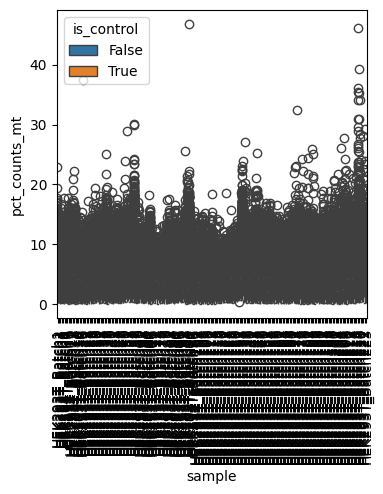

In [63]:
obs['sample'].nunique()
import seaborn as sns
import matplotlib.pyplot as plt

qc_df = obs[['sample', 'is_control', 'pct_counts_mt', 'total_counts']]
sns.boxplot(data=qc_df, x='sample', y='pct_counts_mt', hue='is_control')
plt.xticks(rotation=90)

Number of unique gene and guide targets: 18312 20867


In [ ]:
# Count cells per perturbation target
target_counts = obs[~obs['is_control']]['gene_target'].value_counts()
print(target_counts.describe())  # Summary stats

count    18311.000000
mean       235.675878
std        161.416964
min          1.000000
25%        117.000000
50%        200.000000
75%        319.000000
max       1364.000000
Name: count, dtype: float64


In [ ]:
# filter
valid_targets = target_counts[target_counts >= 30].index
obs_filtered = obs[obs['gene_target'].isin(valid_targets)]

## QC

In [ ]:
# Inspect guide/target coverage

You want to ensure that each gene_target is sufficiently covered:

# - Look at guide effectiveness
	#	Compute expression levels of the gene_target per gene_target group
	#	Compare with control or unperturbed cells to see if knockdown occurs

In [ ]:
import matplotlib.pyplot as plt

sns.histplot(adata.obs['pct_counts_mt'], bins=100)
plt.axvline(10, color='red', linestyle='--', label='10%')
plt.axvline(50, color='orange', linestyle='--', label='50%')
plt.legend()
plt.xlabel('% Mitochondrial counts')
plt.title('Mitochondrial Content Distribution')
plt.show()

### Identify ctr samples 

In [49]:
obs_ctr = obs[(obs['gene_target']=='Non-Targeting')]
print('Number of unique gene and guide targets:', obs_ctr['gene_target'].nunique(), obs_ctr['guide_target'].nunique())
obs_nonctr = obs[(obs['gene_target']!='Non-Targeting')]
print('Number of unique gene and guide targets:', obs_nonctr['gene_target'].nunique(), obs_nonctr['guide_target'].nunique())

Number of unique gene and guide targets: 1 1025
Number of unique gene and guide targets: 18311 19842


In [50]:
obs_nonctr.groupby(['sample_gene_target']).size().sort_values(ascending=False)

sample_gene_target
HEK293T_Batch218_TSPAN33    57
HEK293T_Batch219_RNF166     49
HEK293T_Batch217_CCDC169    41
HEK293T_Batch220_ATP13A2    38
HEK293T_Batch220_YJU2B      34
                            ..
HEK293T_Batch18_TTC16        1
HEK293T_Batch18_TSTD1        1
HEK293T_Batch18_TSSK1B       1
HEK293T_Batch18_TSSC4        1
HEK293T_Batch9_ZZEF1         1
Length: 2109604, dtype: int64

In [18]:
# Count cells per perturbation target
target_counts = adata.obs['gene_target'].value_counts()
print(target_counts.describe())  # Summary stats

count     18312.000000
mean        247.613532
std        1623.469424
min           1.000000
25%         117.000000
50%         200.000000
75%         319.000000
max      218838.000000
Name: count, dtype: float64


In [ ]:

import numpy as np

def compute_knockdown(adata, gene):
    perturbed_cells = adata.obs['gene_target'] == gene
    expr_perturbed = adata[perturbed_cells, gene].X.mean()
    expr_unperturbed = adata[~perturbed_cells, gene].X.mean()
    return expr_unperturbed - expr_perturbed

knockdown_results = {
    gene: compute_knockdown(adata, gene)
    for gene in valid_targets
}

In [17]:
adata.obs.sort_values(by='pct_counts_mt')

,sample,num_features,guide_target,gene_target,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,pass_guide_filter
AACGATAAGCAAGACG-HEK293T_Batch20,HEK293T_Batch20,2,FBXO24_P1P2-1|FBXO24_P1P2-2,FBXO24,4495,12031.0,1.0,0.008312,True
CTGGTCTGTACCCCAT-HEK293T_Batch69,HEK293T_Batch69,2,RGS22_P1P2-1|RGS22_P1P2-2,RGS22,3607,6436.0,1.0,0.015538,True
CAAGGCCGTAGCGGTC-HEK293T_Batch15,HEK293T_Batch15,2,UFSP2_P1P2-1|UFSP2_P1P2-2,UFSP2,7327,27315.0,7.0,0.025627,True
CACTTTCAGCGGGTAA-HEK293T_Batch13,HEK293T_Batch13,2,KLHL36_P2-1|KLHL36_P2-2,KLHL36,8470,32424.0,9.0,0.027757,True
GGTTCGCCAACGTAAG-HEK293T_Batch18,HEK293T_Batch18,2,SRR_P1P2-1|SRR_P1P2-2,SRR,5307,13488.0,4.0,0.029656,True
...,...,...,...,...,...,...,...,...,...
CTCGGTTGTCGAGGCT-HEK293T_Batch217,HEK293T_Batch217,2,MIX23_P1P2-1|MIX23_P1P2-2,MIX23,2947,8505.0,3070.0,36.096416,True
CTATCGCGTGTAATTG-HEK293T_Batch19,HEK293T_Batch19,2,non-targeting_00986|non-targeting_00554,Non-Targeting,3687,10812.0,4042.0,37.384388,True
CAACCCTGTCTATAAG-HEK293T_Batch218,HEK293T_Batch218,2,SLC2A14_P1P2-1|SLC2A14_P1P2-2,SLC2A14,4484,18688.0,7350.0,39.330051,True
ATACCATAGCTAAGCC-HEK293T_Batch217,HEK293T_Batch217,2,MSL1_P1P2-1|MSL1_P1P2-2,MSL1,2633,8723.0,4024.0,46.130920,True


In [13]:
adata.obs.groupby()

,sample,num_features,guide_target,gene_target,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,pass_guide_filter
AAACCAAAGAAGTAGC-HEK293T_Batch1,HEK293T_Batch1,2,FAM180A_P1P2-1|FAM180A_P1P2-2,FAM180A,6856,24243.0,647.0,2.668812,True
AAACCAAAGAGTACGG-HEK293T_Batch1,HEK293T_Batch1,2,non-targeting_03016|non-targeting_03214,Non-Targeting,6636,20847.0,886.0,4.250012,True
AAACCAAAGAGTGGGC-HEK293T_Batch1,HEK293T_Batch1,2,PCDHGC4_P1P2-1|PCDHGC4_P1P2-2,PCDHGC4,5353,14035.0,610.0,4.346277,True
AAACCAAAGAGTGTAA-HEK293T_Batch1,HEK293T_Batch1,2,USP30_P1P2-1|USP30_P1P2-2,USP30,6358,20939.0,589.0,2.812933,True
AAACCAAAGATACGGG-HEK293T_Batch1,HEK293T_Batch1,2,KLRD1_P1P2-1|KLRD1_P1P2-2,KLRD1,5527,14083.0,476.0,3.379961,True
...,...,...,...,...,...,...,...,...,...
GTTGTCCGTGGGATGG-HEK293T_Batch223,HEK293T_Batch223,2,non-targeting_00183|non-targeting_01885,Non-Targeting,8112,29296.0,522.0,1.781813,True
GTTGTCTTCAACAGCC-HEK293T_Batch223,HEK293T_Batch223,2,AKAP13_P1P2-1|AKAP13_P1P2-2,AKAP13,10568,88551.0,3035.0,3.427403,True
GTTGTCTTCAGTACTG-HEK293T_Batch223,HEK293T_Batch223,2,TTF2_P1P2-1|TTF2_P1P2-2,TTF2,10735,81286.0,1808.0,2.224245,True
GTTGTCTTCCGCCGTT-HEK293T_Batch223,HEK293T_Batch223,2,MMP7_P1P2-1|MMP7_P1P2-2,MMP7,9248,40733.0,1767.0,4.338006,True
